## Análisis Exploratorio de Datos (EDA)

### ¿Qué es el EDA?

El **Análisis Exploratorio de Datos (Exploratory Data Analysis, EDA)** es el proceso de examinar un conjunto de datos con el objetivo de entender su estructura, detectar patrones, identificar anomalías y resumir sus características principales antes de aplicar modelos estadísticos o de machine learning.

El EDA no se centra en confirmar hipótesis, sino en **explorar y comprender los datos**.

---

## Objetivos del EDA

- Comprender la estructura general del dataset
- Identificar tipos de variables (numéricas, categóricas, ordinales)
- Detectar valores faltantes o inconsistencias
- Analizar distribuciones de las variables
- Detectar valores atípicos (outliers)
- Identificar relaciones entre variables
- Generar hipótesis para análisis posteriores

---

##  Métodos comunes en EDA

### 1. Estadística descriptiva
- Media, mediana, varianza, desviación estándar
- Cuartiles y percentiles
- Resúmenes con `describe()`

---

### 2. Análisis de valores faltantes
- Conteo de NA
- Porcentaje de datos incompletos
- Patrones de missingness

---

### 3. Visualización univariada
- Histogramas
- Densidad
- Boxplots

---

### 4. Visualización bivariada y multivariada
- Scatter plots
- Pairplots
- Heatmaps de correlación

---

### 5. Análisis de correlación
- Matriz de correlación
- Relaciones lineales entre variables
- Pruebas de independencia

---

### 6. Pruebas de bondad de ajuste
- Shapiro–Wilk
- Kolmogorov–Smirnov
- Anderson–Darling
- Jarque–Bera

---

### 7. Análisis por grupos
- Comparación entre categorías 
- Boxplots por grupo

---

##  ¿Qué se busca en el EDA?

- Forma de las distribuciones (normalidad, sesgo)
- Relaciones entre variables (lineales o no lineales)
- Presencia de outliers
- Diferencias entre grupos
- Posibles variables predictoras
- Estructura general del fenómeno estudiado

---

##  Precauciones importantes

- No asumir causalidad a partir de correlaciones
- Tener cuidado con outliers (pueden distorsionar análisis)
- Evitar conclusiones sin pruebas formales
- Considerar el tamaño de muestra
- No sobreinterpretar gráficos
- Diferenciar entre correlación y dependencia estadística

---

## Aspectos importantes

- El EDA es un paso **previo a cualquier modelado**
- Es iterativo: se ajusta conforme se descubren patrones
- Combina estadística + visualización
- Permite detectar problemas antes de modelar (errores, sesgos, ruido)

---


El EDA es una etapa fundamental en el análisis de datos, ya que permite transformar un conjunto de datos sin estructura aparente en información comprensible, guiando el análisis estadístico y la construcción de modelos posteriores.

In [108]:
import pandas as pd
import numpy as np
import zipfile
import requests
from io import BytesIO

In [35]:
url_data = "https://datosabiertos.salud.gob.mx/gobmx/salud/datos_abiertos/efe/datos_abiertos_efe.zip"

response = requests.get(url_data)
zip_file = zipfile.ZipFile(BytesIO(response.content))

# Ver archivos dentro del zip
zip_file.namelist()

['efes_abierto_15.csv', '__MACOSX/._efes_abierto_15.csv']

In [36]:
df = pd.read_csv(zip_file.open('efes_abierto_15.csv'), encoding='latin-1') #corregir nombre si es necesario
df.head()

,FECHA_ACTUALIZACION,ID_REGISTRO,EDAD_ANOS,EDAD_MESES,EDAD_DIAS,SEXO,HABLA_LENGUA_INDIG,INDIGENA,ENTIDAD_UM_NOTIF,MUNICIPIO_UM_NOTIF,...,INSTITUCION_NOTIF,VACUNACION,EXANTEMA,FIEBRE,COMPLICACIONES,DEFUNCION,DIAGNOSTICO,CRITERIO_DIAGNOSTICO,FECHA_DIAGNOSTICO,ORIGEN_CASO
0,2026-04-20,49817,7,8,7,1,2,2,29,25,...,20,2,1,1,2,2,3,2,2026-01-27,5.0
1,2026-04-20,49840,10,7,0,2,2,2,14,101,...,4,2,1,1,2,2,3,2,2026-01-31,5.0
2,2026-04-20,49865,58,8,7,2,2,2,14,120,...,12,2,1,1,2,2,1,2,2026-01-28,4.0
3,2026-04-20,49882,6,9,29,2,2,2,14,101,...,4,2,1,1,2,2,1,2,2026-02-06,2.0
4,2026-04-20,49892,1,9,3,2,2,2,21,47,...,12,1,1,1,2,2,3,2,2026-01-30,5.0


In [37]:
df.describe()

,ID_REGISTRO,EDAD_ANOS,EDAD_MESES,EDAD_DIAS,SEXO,HABLA_LENGUA_INDIG,INDIGENA,ENTIDAD_UM_NOTIF,MUNICIPIO_UM_NOTIF,ENTIDAD_RES,MUNICIPIO_RES,INSTITUCION_NOTIF,VACUNACION,EXANTEMA,FIEBRE,COMPLICACIONES,DEFUNCION,DIAGNOSTICO,CRITERIO_DIAGNOSTICO,ORIGEN_CASO
count,23203.000000,23203.000000,23203.000000,23203.000000,23203.000000,23203.000000,23203.000000,23203.000000,23203.000000,23203.000000,23203.000000,23203.000000,23203.000000,23203.0,23203.0,23203.000000,23203.000000,23203.000000,23203.000000,23023.000000
mean,58578.034651,17.487480,5.472094,14.482653,1.521958,1.945309,1.945309,14.345343,52.883981,14.412188,56.771064,16.751239,1.661811,1.0,1.0,1.950912,1.998664,1.573503,1.593630,4.285931
std,6777.868858,15.918213,3.393691,8.810687,0.499528,0.227381,0.227381,6.416551,44.568003,6.393990,46.260837,25.446275,0.473103,0.0,0.0,0.216057,0.036528,1.183591,0.802369,1.044670
min,46797.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.0,1.0,1.000000,1.000000,0.000000,0.000000,1.000000
25%,52708.500000,3.000000,3.000000,7.000000,1.000000,2.000000,2.000000,9.000000,15.000000,10.000000,15.000000,4.000000,1.000000,1.0,1.0,2.000000,2.000000,1.000000,2.000000,4.000000
50%,58596.000000,13.000000,5.000000,14.000000,2.000000,2.000000,2.000000,14.000000,39.000000,14.000000,43.000000,6.000000,2.000000,1.0,1.0,2.000000,2.000000,1.000000,2.000000,5.000000
75%,64456.500000,30.000000,8.000000,22.000000,2.000000,2.000000,2.000000,16.000000,98.000000,16.000000,98.000000,20.000000,2.000000,1.0,1.0,2.000000,2.000000,3.000000,2.000000,5.000000
max,70279.000000,106.000000,11.000000,30.000000,2.000000,2.000000,2.000000,32.000000,559.000000,34.000000,565.000000,99.000000,2.000000,1.0,1.0,2.000000,2.000000,3.000000,2.000000,5.000000


In [38]:
url_dict = "https://datosabiertos.salud.gob.mx/gobmx/salud/datos_abiertos/efe/diccionario_datos_efe.zip"

response_dict = requests.get(url_dict)
zip_dict = zipfile.ZipFile(BytesIO(response_dict.content))

zip_dict.namelist()

['20201123_Catálogos_EFEs.xlsx', '20201123_Descriptores_EFEs.xlsx']

In [39]:
pip install openpyxl


[notice] A new release of pip is available: 25.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [40]:
catalogos = pd.read_excel(zip_dict.open('20201123_Catálogos_EFEs.xlsx'), sheet_name=None)

# Ver nombres de hojas
catalogos.keys()

dict_keys(['CATÁLOGO INSTITUCIÓN', 'CATÁLOGO ORIGEN_CASO', 'CATÁLOGO CRITERIO_DIAGNOSTICO', 'CATÁLOGO DIAGNOSTICO', 'CATÁLOGO MUNICIPIOS', 'CATÁLOGO ENTIDADES', 'Catálogo SEXO', 'Catálogo SI_NO'])

In [41]:
def crear_diccionario(df_catalogo):
    df_catalogo = df_catalogo.dropna()

    # Tomar solo primeras dos columnas
    df_catalogo = df_catalogo.iloc[:, :2]

    # Renombrar por claridad
    df_catalogo.columns = ['codigo', 'descripcion']

    return dict(zip(df_catalogo['codigo'], df_catalogo['descripcion']))

In [42]:
diccionarios = {}

for nombre_hoja, df_cat in catalogos.items():
    try:
        diccionarios[nombre_hoja] = crear_diccionario(df_cat)
    except:
        pass

In [43]:
diccionarios

{'CATÁLOGO INSTITUCIÓN': {1: 'CRUZ ROJA',
  2: 'DIF',
  3: 'ESTATAL',
  4: 'IMSS',
  5: 'IMSS-BIENESTAR',
  6: 'ISSSTE',
  7: 'MUNICIPAL',
  8: 'PEMEX',
  9: 'PRIVADA',
  10: 'SEDENA',
  11: 'SEMAR',
  12: 'SSA',
  13: 'UNIVERSITARIO',
  99: 'NO ESPECIFICADO'},
 'CATÁLOGO ORIGEN_CASO': {1: 'IMPORTADO',
  2: 'RELACIONADO A IMPORTACIÓN',
  3: 'AUTÓCTONO',
  4: 'FUENTE DESCONOCIDA',
  5: 'NO APLICA'},
 'CATÁLOGO CRITERIO_DIAGNOSTICO': {0: 'SIN DIAGNÓSTICO ',
  1: 'CLÍNICO-EPIDEMIOLÓGICO',
  2: 'LABORATORIO'},
 'CATÁLOGO DIAGNOSTICO': {0: 'SIN DIAGNÓSTICO',
  1: 'SARAMPIÓN',
  2: 'RUBÉOLA',
  3: 'DESCARTADO'},
 'CATÁLOGO MUNICIPIOS': {1: 'APOZOL',
  2: 'APULCO',
  3: 'ATOLINGA',
  4: 'BENITO JUÁREZ',
  5: 'CALERA',
  6: 'CAÑITAS DE FELIPE PESCADOR',
  7: 'CONCEPCIÓN DEL ORO',
  8: 'CUAUHTÉMOC',
  9: 'CHALCHIHUITES',
  10: 'FRESNILLO',
  11: 'TRINIDAD GARCÍA DE LA CADENA',
  999: 'NO ESPECIFICADO',
  12: 'GENARO CODINA',
  13: 'GENERAL ENRIQUE ESTRADA',
  14: 'GENERAL FRANCISCO R. MURGUÍA',

In [44]:
mapa_variables = {
    'SEXO': 'Catálogo SEXO',
    'HABLA_LENGUA_INDIG': 'Catálogo SI_NO',
    'INDIGENA': 'Catálogo SI_NO',
    'ENTIDAD_UM_NOTIF': 'CATÁLOGO ENTIDADES',
    'MUNICIPIO_UM_NOTIF': 'CATÁLOGO MUNICIPIOS',
    'ENTIDAD_RES': 'CATÁLOGO ENTIDADES',
    'MUNICIPIO_RES': 'CATÁLOGO MUNICIPIOS',
    'INSTITUCION_NOTIF': 'CATÁLOGO INSTITUCIÓN',
    'VACUNACION': 'Catálogo SI_NO',
    'EXANTEMA': 'Catálogo SI_NO',
    'FIEBRE': 'Catálogo SI_NO',
    'COMPLICACIONES': 'Catálogo SI_NO',
    'DEFUNCION': 'Catálogo SI_NO',
    'DIAGNOSTICO': 'CATÁLOGO DIAGNOSTICO',
    'CRITERIO_DIAGNOSTICO': 'CATÁLOGO CRITERIO_DIAGNOSTICO',
    'ORIGEN_CASO': 'CATÁLOGO ORIGEN_CASO'
}

In [45]:
for columna, nombre_catalogo in mapa_variables.items():

    if columna in df.columns and nombre_catalogo in diccionarios:

        df[columna] = df[columna].map(diccionarios[nombre_catalogo])

In [46]:
df[['EDAD_ANOS', 'SEXO', 'DEFUNCION', 'DIAGNOSTICO']].head()

,EDAD_ANOS,SEXO,DEFUNCION,DIAGNOSTICO
0,7,MUJER,NO,DESCARTADO
1,10,HOMBRE,NO,DESCARTADO
2,58,HOMBRE,NO,SARAMPIÓN
3,6,HOMBRE,NO,SARAMPIÓN
4,1,HOMBRE,NO,DESCARTADO


In [47]:
df['FECHA_ACTUALIZACION'] = pd.to_datetime(df['FECHA_ACTUALIZACION'], dayfirst=True, errors='coerce')
df['FECHA_DIAGNOSTICO'] = pd.to_datetime(df['FECHA_DIAGNOSTICO'], dayfirst=True, errors='coerce')

C:\Users\victo\AppData\Local\Temp\ipykernel_9376\822570009.py:1: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['FECHA_ACTUALIZACION'] = pd.to_datetime(df['FECHA_ACTUALIZACION'], dayfirst=True, errors='coerce')
C:\Users\victo\AppData\Local\Temp\ipykernel_9376\822570009.py:2: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['FECHA_DIAGNOSTICO'] = pd.to_datetime(df['FECHA_DIAGNOSTICO'], dayfirst=True, errors='coerce')


In [48]:
#df['EDAD_TOTAL'] = df['EDAD_ANOS'] + df['EDAD_MESES']/12 + df['EDAD_DIAS']/365

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23203 entries, 0 to 23202
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   FECHA_ACTUALIZACION   23203 non-null  datetime64[ns]
 1   ID_REGISTRO           23203 non-null  int64         
 2   EDAD_ANOS             23203 non-null  int64         
 3   EDAD_MESES            23203 non-null  int64         
 4   EDAD_DIAS             23203 non-null  int64         
 5   SEXO                  23203 non-null  object        
 6   HABLA_LENGUA_INDIG    23203 non-null  object        
 7   INDIGENA              23203 non-null  object        
 8   ENTIDAD_UM_NOTIF      23203 non-null  object        
 9   MUNICIPIO_UM_NOTIF    23203 non-null  object        
 10  ENTIDAD_RES           23201 non-null  object        
 11  MUNICIPIO_RES         23203 non-null  object        
 12  INSTITUCION_NOTIF     18686 non-null  object        
 13  VACUNACION      

In [50]:
df.isnull().sum().sort_values(ascending=False)

INSTITUCION_NOTIF       4517
FECHA_DIAGNOSTICO       4508
ORIGEN_CASO              180
ENTIDAD_RES                2
FECHA_ACTUALIZACION        0
ID_REGISTRO                0
SEXO                       0
EDAD_DIAS                  0
EDAD_MESES                 0
EDAD_ANOS                  0
MUNICIPIO_UM_NOTIF         0
ENTIDAD_UM_NOTIF           0
HABLA_LENGUA_INDIG         0
INDIGENA                   0
VACUNACION                 0
MUNICIPIO_RES              0
EXANTEMA                   0
FIEBRE                     0
DEFUNCION                  0
COMPLICACIONES             0
CRITERIO_DIAGNOSTICO       0
DIAGNOSTICO                0
dtype: int64

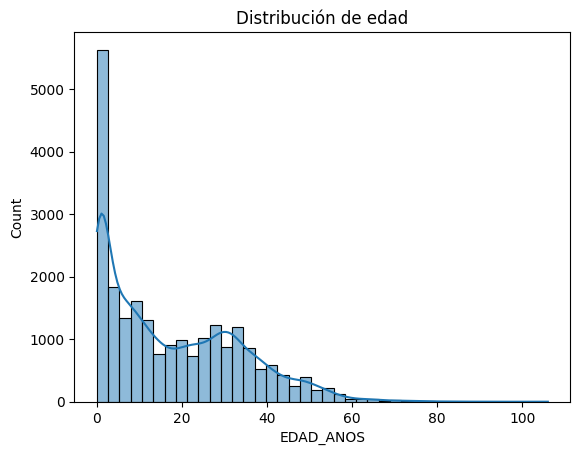

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['EDAD_ANOS'], bins=40, kde=True)
plt.title("Distribución de edad")
plt.show()

In [52]:
df['SEXO'].value_counts(normalize=True)

SEXO
HOMBRE    0.521958
MUJER     0.478042
Name: proportion, dtype: float64

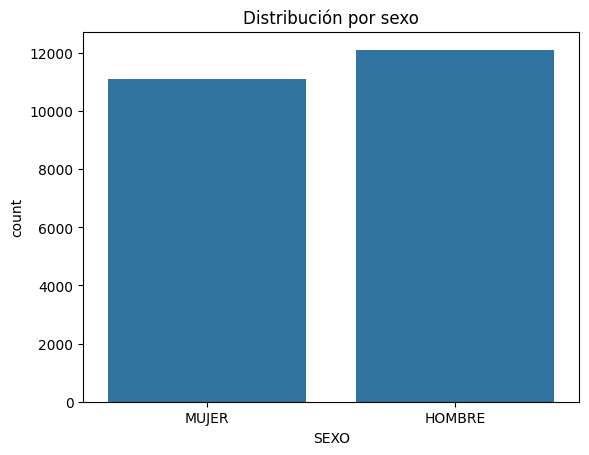

In [53]:
sns.countplot(x='SEXO', data=df)
plt.title("Distribución por sexo")
plt.show()

FIEBRE
SI     1.0
Name: proportion, dtype: float64


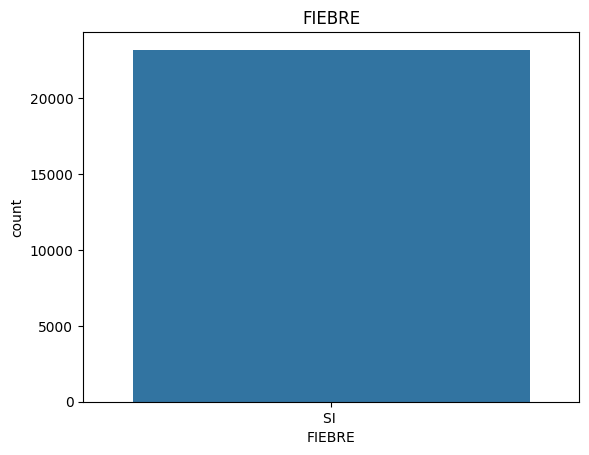

EXANTEMA
SI     1.0
Name: proportion, dtype: float64


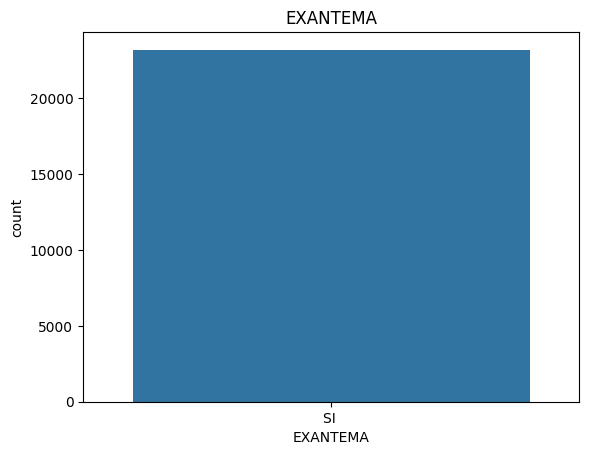

COMPLICACIONES
NO     0.950912
SI     0.049088
Name: proportion, dtype: float64


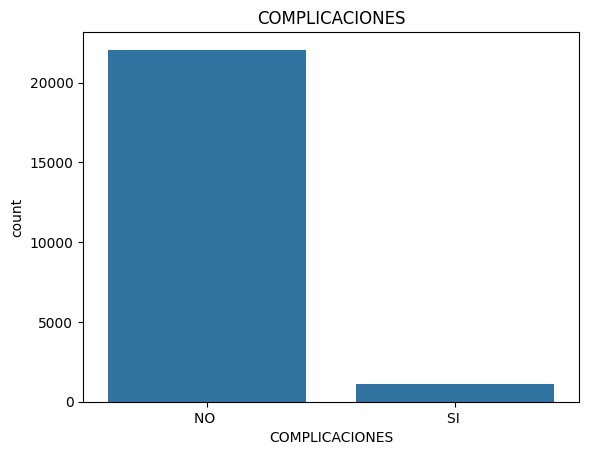

In [54]:
cols = ['FIEBRE', 'EXANTEMA', 'COMPLICACIONES']

for col in cols:
    print(df[col].value_counts(normalize=True))
    sns.countplot(x=col, data=df)
    plt.title(col)
    plt.show()

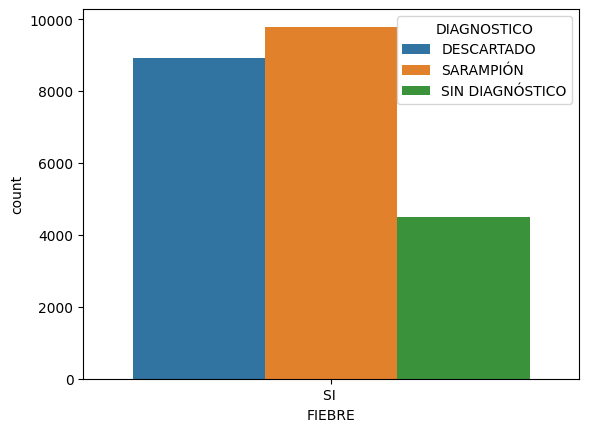

In [55]:
sns.countplot(x='FIEBRE', hue='DIAGNOSTICO', data=df)
plt.show()

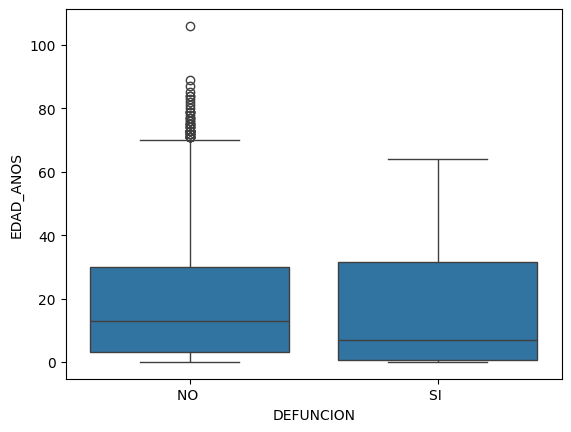

In [56]:
sns.boxplot(x='DEFUNCION', y='EDAD_ANOS', data=df)
plt.show()

In [57]:
pd.crosstab(df['SEXO'], df['DEFUNCION'], normalize='index')

DEFUNCION,NO,SI
SEXO,,
HOMBRE,0.998679,0.001321
MUJER,0.998648,0.001352


### Ejemplo Prueba de independencia

In [67]:
import pandas as pd

# Tabla de contingencia con proporciones por fila
tabla_prop = pd.crosstab(df['SEXO'], df['DEFUNCION'], normalize='index')

print("Proporciones condicionales (por sexo):")
print(tabla_prop)

Proporciones condicionales (por sexo):
DEFUNCION       NO        SI 
SEXO                         
HOMBRE     0.998679  0.001321
MUJER      0.998648  0.001352


In [70]:
from scipy.stats import chi2_contingency

# Tabla de frecuencias 
tabla = pd.crosstab(df['SEXO'], df['DEFUNCION'])

chi2, p, dof, expected = chi2_contingency(tabla)

print("Chi-cuadrado:", chi2)
print("p-valor:", p)


Chi-cuadrado: 0.0
p-valor: 1.0


### Otras pruebas de independencia a variables categóricas

In [107]:
import pandas as pd
import numpy as np
from itertools import combinations
from scipy.stats import chi2_contingency, fisher_exact

# Selección de variables categóricas relevantes
cat_vars = [
    "SEXO",
    "DEFUNCION",
    "VACUNACION",
    "COMPLICACIONES",
    "FIEBRE",
    "EXANTEMA"
]

resultados = []

for var1, var2 in combinations(cat_vars, 2):
    
    # Tabla de contingencia
    tabla = pd.crosstab(df[var1], df[var2])
    
    # Evitar tablas vacías
    if tabla.size == 0:
        continue
    
    # Chi-cuadrado
    chi2, p_chi2, dof, expected = chi2_contingency(tabla)
    
    # V de Cramér
    n = tabla.values.sum()
    k = min(tabla.shape)
    cramer_v = np.sqrt(chi2 / (n * (k - 1))) if k > 1 else np.nan
    
    # Fisher (solo 2x2)
    if tabla.shape == (2, 2):
        oddsratio, p_fisher = fisher_exact(tabla)
    else:
        oddsratio, p_fisher = np.nan, np.nan
    
    resultados.append({
        "Var1": var1,
        "Var2": var2,
        "Chi2 p-valor": p_chi2,
        #"Fisher p-valor": p_fisher,
        "Cramer V": cramer_v
    })

df_resultados = pd.DataFrame(resultados)

# Ordenar por evidencia de dependencia
df_resultados.sort_values(by="Chi2 p-valor")

,Var1,Var2,Chi2 p-valor,Cramer V
6,DEFUNCION,COMPLICACIONES,5.069709e-62,0.109103
9,VACUNACION,COMPLICACIONES,5.726132e-28,0.071974
1,SEXO,VACUNACION,3.899418e-02,0.013552
5,DEFUNCION,VACUNACION,1.301665e-01,0.009936
2,SEXO,COMPLICACIONES,7.605236e-01,0.002001
3,SEXO,FIEBRE,1.000000e+00,NaN
4,SEXO,EXANTEMA,1.000000e+00,NaN
0,SEXO,DEFUNCION,1.000000e+00,0.000000
7,DEFUNCION,FIEBRE,1.000000e+00,NaN
8,DEFUNCION,EXANTEMA,1.000000e+00,NaN


### Análisis Geográfico

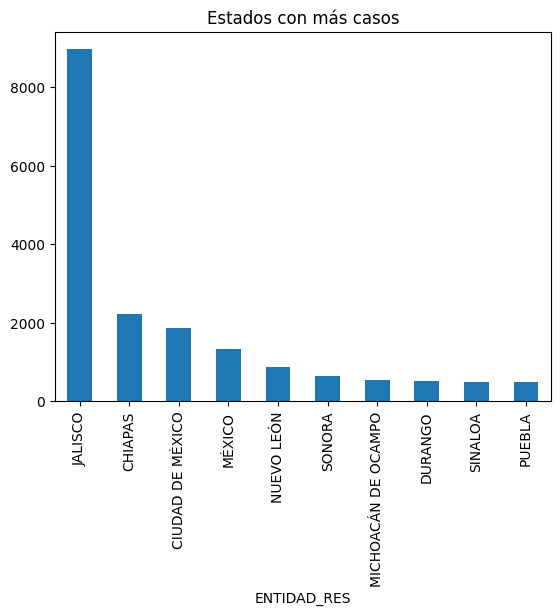

In [58]:
top_states = df['ENTIDAD_RES'].value_counts().head(10)

top_states.plot(kind='bar')
plt.title("Estados con más casos")
plt.show()

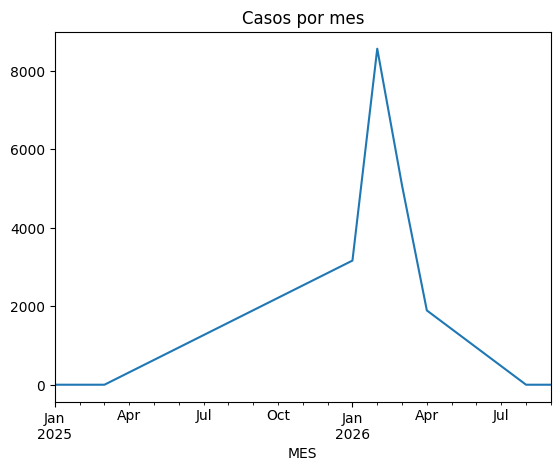

In [59]:
df['MES'] = df['FECHA_DIAGNOSTICO'].dt.to_period('M')

df.groupby('MES').size().plot()
plt.title("Casos por mes")
plt.show()

### Con el fin de hacer un EDA más completo simularemos algunas variables como: altura, peso,  IMC, presión sistólica  y diastólica.

In [88]:
import numpy as np

np.random.seed(42)

# =========================
# 1. ALTURA (cm)
# =========================
# crecimiento básico por edad (simplificado)
df["ALTURA"] = (
    50 + df["EDAD_ANOS"] * 6
    + np.random.normal(0, 5, len(df))
)

# =========================
# 2. PESO (kg)
# =========================
df["PESO"] = (
    3 + df["EDAD_ANOS"] * 2.5
    + np.random.normal(0, 3, len(df))
)

# =========================
# 3. IMC
# =========================
df["IMC"] = df["PESO"] / ((df["ALTURA"] / 100) ** 2)

# =========================
# 4. PRESIÓN SISTÓLICA
# =========================
df["PRESION_SISTOLICA"] = (
    90 
    + np.random.normal(0, 10, len(df))
)

# =========================
# 5. PRESIÓN DIASTÓLICA
# =========================
df["PRESION_DIASTOLICA"] = (
    60 
    + np.random.normal(0, 8, len(df))
)

In [89]:
df.head()

,FECHA_ACTUALIZACION,ID_REGISTRO,EDAD_ANOS,EDAD_MESES,EDAD_DIAS,SEXO,HABLA_LENGUA_INDIG,INDIGENA,ENTIDAD_UM_NOTIF,MUNICIPIO_UM_NOTIF,...,DIAGNOSTICO,CRITERIO_DIAGNOSTICO,FECHA_DIAGNOSTICO,ORIGEN_CASO,MES,ALTURA,PESO,IMC,PRESION_SISTOLICA,PRESION_DIASTOLICA
0,2026-04-20,49817,7,8,7,MUJER,NO,NO,TLAXCALA,LUIS MOYA,...,DESCARTADO,LABORATORIO,2026-01-27,NO APLICA,2026-01,94.483571,12.734923,14.265392,93.549215,58.025187
1,2026-04-20,49840,10,7,0,HOMBRE,NO,NO,JALISCO,UMÁN,...,DESCARTADO,LABORATORIO,2026-01-31,NO APLICA,2026-01,109.308678,28.050759,23.476607,104.612840,60.338869
2,2026-04-20,49865,58,8,7,HOMBRE,NO,NO,JALISCO,OTEAPAN,...,SARAMPIÓN,LABORATORIO,2026-01-28,FUENTE DESCONOCIDA,2026-01,401.238443,145.761637,9.053952,88.308809,74.470320
3,2026-04-20,49882,6,9,29,HOMBRE,NO,NO,JALISCO,UMÁN,...,SARAMPIÓN,LABORATORIO,2026-02-06,RELACIONADO A IMPORTACIÓN,2026-02,93.615149,22.207088,25.339576,81.372057,71.480328
4,2026-04-20,49892,1,9,3,HOMBRE,NO,NO,PUEBLA,TEÚL DE GONZÁLEZ ORTEGA,...,DESCARTADO,LABORATORIO,2026-01-30,NO APLICA,2026-01,54.829233,14.328258,47.661647,109.188693,56.898339


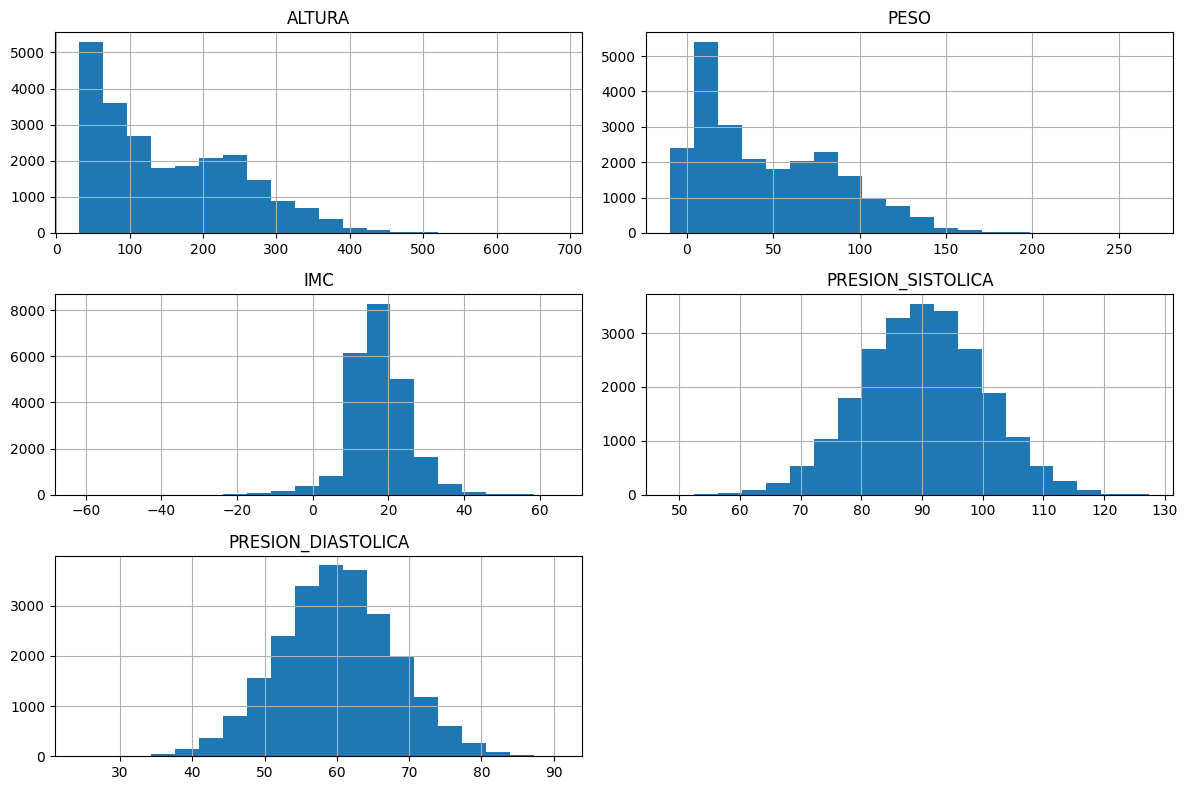

In [90]:
import matplotlib.pyplot as plt

num_vars = ["ALTURA", "PESO", "IMC", "PRESION_SISTOLICA", "PRESION_DIASTOLICA"]

df[num_vars].hist(bins=20, figsize=(12,8))
plt.tight_layout()
plt.show()

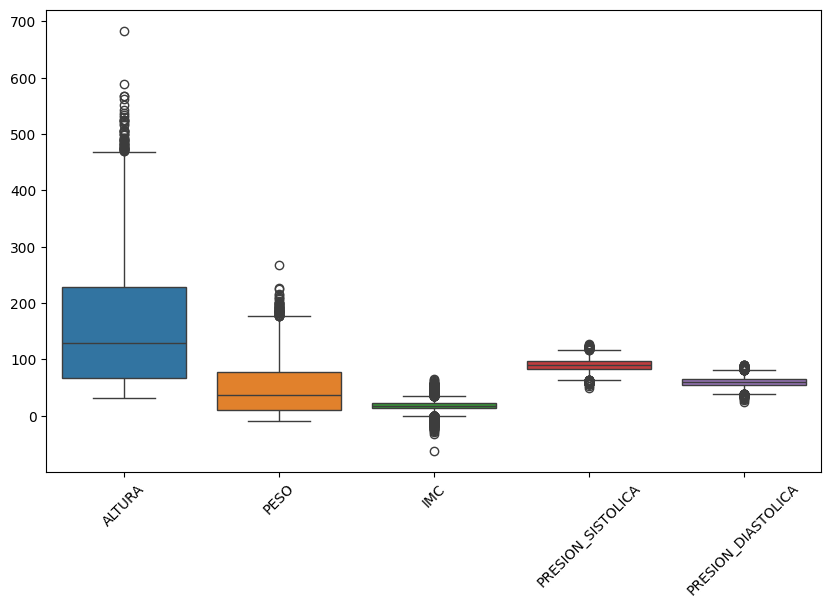

In [92]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.boxplot(data=df[num_vars])
plt.xticks(rotation=45)
plt.show()

### Pruebas de Normalidad

In [91]:
import numpy as np
import pandas as pd
from scipy.stats import shapiro, kstest, anderson, chisquare, norm, jarque_bera

resultados = []

for var in num_vars:
    data = df[var].dropna()
    
    # -------------------------
    # 1. Shapiro-Wilk
    # -------------------------
    stat_shapiro, p_shapiro = shapiro(data)
    
    # -------------------------
    # 2. Kolmogorov-Smirnov
    # -------------------------
    data_std = (data - np.mean(data)) / np.std(data)
    stat_ks, p_ks = kstest(data_std, 'norm')
    
    # -------------------------
    # 3. Anderson-Darling
    # -------------------------
    ad_result = anderson(data, dist='norm')
    
    # -------------------------
    # 4. Chi-cuadrado
    # -------------------------
    k = int(np.sqrt(len(data)))
    obs_freq, bin_edges = np.histogram(data, bins=k)
    
    mu, sigma = np.mean(data), np.std(data)
    
    expected_probs = [
        norm.cdf(bin_edges[i+1], mu, sigma) - norm.cdf(bin_edges[i], mu, sigma)
        for i in range(len(bin_edges)-1)
    ]
    
    expected_freq = np.array(expected_probs) * len(data)
    
    mask = expected_freq > 0
    obs_freq = obs_freq[mask]
    expected_freq = expected_freq[mask]
    
    expected_freq = expected_freq * (obs_freq.sum() / expected_freq.sum())
    
    stat_chi2, p_chi2 = chisquare(obs_freq, expected_freq)
    
    # -------------------------
    # 5. Jarque-Bera
    # -------------------------
    stat_jb, p_jb = jarque_bera(data)
    
    # -------------------------
    # Guardar resultados
    # -------------------------
    resultados.append({
        "Variable": var,
        "Shapiro p": p_shapiro,
        "KS p": p_ks,
        "Chi2 p": p_chi2,
        "Jarque-Bera p": p_jb,
        "Anderson stat": ad_result.statistic
    })

df_resultados = pd.DataFrame(resultados)
df_resultados

c:\Users\victo\AppData\Local\Programs\Python\Python39\lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 23203.
  res = hypotest_fun_out(*samples, **kwds)


,Variable,Shapiro p,KS p,Chi2 p,Jarque-Bera p,Anderson stat
0,ALTURA,3.522416e-77,4.024267e-285,0.000000,0.000000,644.738147
1,PESO,2.742550e-76,8.347748e-289,0.000000,0.000000,621.922830
2,IMC,1.210829e-59,7.976006e-102,0.000000,0.000000,183.721064
3,PRESION_SISTOLICA,7.070699e-01,8.816361e-01,0.785969,0.189318,0.304641
4,PRESION_DIASTOLICA,6.191666e-01,3.913249e-01,0.184404,0.444456,0.478169


In [102]:
import pandas as pd
from itertools import combinations
from scipy.stats import pearsonr, spearmanr, kendalltau

resultados = []

for var1, var2 in combinations(num_vars, 2):
    x = df[var1].dropna()
    y = df[var2].dropna()
    
    # Alinear tamaños
    data = pd.concat([x, y], axis=1).dropna()
    x = data.iloc[:, 0]
    y = data.iloc[:, 1]
    
    # Pearson
    r_p, p_p = pearsonr(x, y)
    
    # Spearman
    r_s, p_s = spearmanr(x, y)
    
    # Kendall
    tau, p_k = kendalltau(x, y)
    
    resultados.append({
        "Var1": var1,
        "Var2": var2,
        "Pearson r": r_p,
        "Pearson p": p_p,
        "Spearman rho": r_s,
        "Spearman p": p_s,
        "Kendall tau": tau,
        "Kendall p": p_k
    })

df_corr = pd.DataFrame(resultados)
df_corr

,Var1,Var2,Pearson r,Pearson p,Spearman rho,Spearman p,Kendall tau,Kendall p
0,ALTURA,PESO,0.995824,0.000000,0.985554,0.000000,0.907693,0.000000
1,ALTURA,IMC,-0.358210,0.000000,-0.396309,0.000000,-0.400220,0.000000
2,ALTURA,PRESION_SISTOLICA,0.003933,0.549106,0.006036,0.357873,0.003998,0.361013
3,ALTURA,PRESION_DIASTOLICA,-0.003903,0.552220,-0.002163,0.741767,-0.001443,0.741572
4,PESO,IMC,-0.307879,0.000000,-0.299623,0.000000,-0.308038,0.000000
5,PESO,PRESION_SISTOLICA,0.004043,0.537994,0.006759,0.303251,0.004481,0.305935
6,PESO,PRESION_DIASTOLICA,-0.004610,0.482534,-0.003193,0.626737,-0.002132,0.626153
7,IMC,PRESION_SISTOLICA,0.003769,0.565919,0.001294,0.843770,0.000875,0.841581
8,IMC,PRESION_DIASTOLICA,-0.010780,0.100571,-0.008862,0.177078,-0.005889,0.178470
9,PRESION_SISTOLICA,PRESION_DIASTOLICA,-0.004494,0.493628,-0.005666,0.388138,-0.003772,0.388755


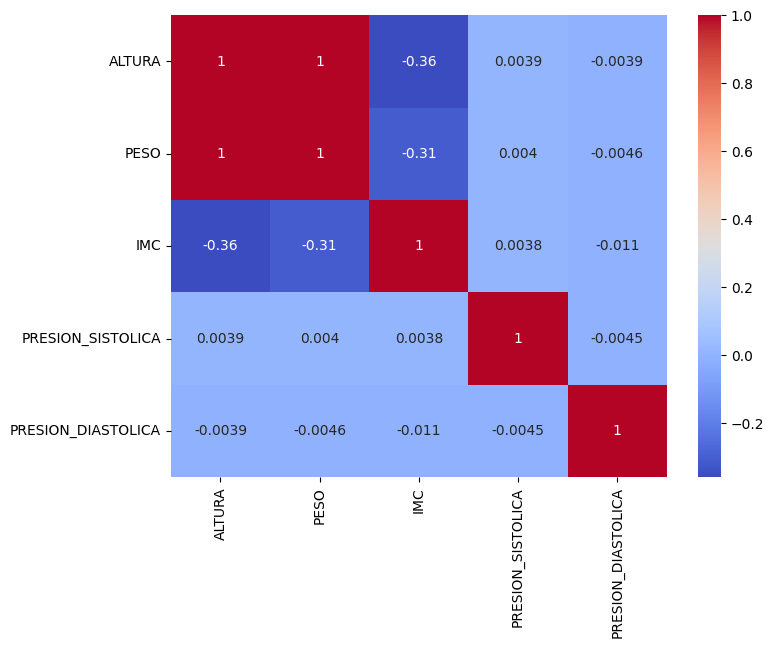

In [93]:
plt.figure(figsize=(8,6))
sns.heatmap(df[num_vars].corr(), annot=True, cmap="coolwarm")
plt.show()

## Conclusión: Importancia del Análisis Exploratorio de Datos (EDA)

El Análisis Exploratorio de Datos (EDA) es una etapa fundamental en cualquier estudio estadístico o proyecto de ciencia de datos, ya que permite comprender la estructura, calidad y comportamiento de los datos antes de aplicar modelos o inferencias formales.

A través del EDA se pueden:

- Identificar patrones, relaciones y posibles dependencias entre variables  
- Detectar valores atípicos, errores o inconsistencias en los datos  
- Evaluar supuestos estadísticos (como normalidad o independencia)  
- Seleccionar métodos adecuados de análisis según el tipo de variables  
- Generar hipótesis preliminares basadas en evidencia empírica  

En particular, el uso combinado de:
- visualizaciones (histogramas, gráficos de dispersión, tablas de contingencia),
- medidas descriptivas,
- y pruebas estadísticas,

permite obtener una visión integral del comportamiento de los datos.

Además, el EDA evita conclusiones erróneas, ya que ayuda a contextualizar los resultados de pruebas formales, especialmente en escenarios con muestras grandes donde los p-valores pueden ser engañosos (muy importante compementar con gráficos).

En resumen, el EDA no es un paso opcional, sino una fase crítica que guía y da sustento a todo el análisis posterior, asegurando que las decisiones estadísticas sean informadas, coherentes y relevantes.

## Referencias sobre Análisis Exploratorio de Datos (EDA)

- Tukey, J. W. (1977). *Exploratory Data Analysis*. Addison-Wesley.  


- Oluleye, A. (2023). Exploratory Data Analysis with Python Cookbook: Over 50 recipes to analyze, visualize, and extract insights from structured and unstructured data. Packt Publishing Ltd.